# Player Elo ratings from real match data

Turn the raw `data_test.xlsx` match file into a per-player Elo time series and export it.

Ratings implement Wolf, Schmitt & Schuller (2020), formulas (6)-(10): a team's strength is the
minutes-weighted mean of its line-up, and each player is nudged by their personal goal
difference vs. the Elo-expected result. Ratings follow the **person** across teams/seasons.

Output: one row per appearance — `Player, season, round, team_at, rating` (rating = **after** the match).

In [1]:
from pathlib import Path
import sys

root = Path.cwd()
while not (root / "data_test.xlsx").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

import pandas as pd
import matplotlib.pyplot as plt
from dfg_rating.model import factory
from dfg_rating.model.network.base_network import WhiteNetwork
from dfg_rating.model.rating.player_elo_rating import PlayerELORating

## Load and shape
The file has one row per match, line-ups as per-side JSON lists, and **no round column**. We use
`home_score_x`/`away_score_x` as the score, and synthesize `round` = chronological match index
per season. The `player-soccer-lists` mapping parses the list columns and drops noise tokens
(e.g. `red_card_1`).

In [2]:
df = pd.read_excel(root / "data_test.xlsx").rename(
    columns={"home_score_x": "home_score", "away_score_x": "away_score"})
df = df.sort_values(["season_id", "date"]).reset_index(drop=True)
df["round"] = df.groupby("season_id").cumcount() + 1

net = WhiteNetwork(data=df, mapping=factory.pre_mappings["player-soccer-lists"])
print(f"{len(df)} matches | {df['season_id'].nunique()} season | {len(net.players)} players")

Network loaded correctly
8775 matches | 1 season | 11981 players


## Compute and export
One chronological pass (defaults `k=32`, `q=0.75`, new players start at 1000), then export.

In [3]:
net.add_player_rating(PlayerELORating(k=32, q=0.75, initial_rating=1000))
out = net.export_player_match_ratings(filename=str(root / "player_ratings.csv"))
out.head()

,Player,season,round,team_at,rating,date
0,A. Jung,14,308,KV Oostende,984.000000,2023-08-13 16:00:00
1,A. Jung,14,497,KV Oostende,967.951144,2023-08-19 20:00:00
2,A. Jung,14,762,KV Oostende,949.715002,2023-08-27 16:00:00
3,A. Jung,14,953,FC Valenciennes,949.965035,2023-09-02 19:00:00
4,A. Jung,14,1196,FC Valenciennes,939.318288,2023-09-16 19:00:00


## Example — FC Barcelona
Latest ratings of Barça's most-used players, and Lewandowski's trajectory over the season.

In [4]:
barca = out[out.team_at == "FC Barcelona"]
latest = (barca.sort_values("round").groupby("Player")
          .agg(apps=("rating", "size"), rating=("rating", "last")))
latest.sort_values("rating", ascending=False).head(10)

,apps,rating
Player,,
ter Stegen M.-A.,34,1212.684427
Lewandowski R.,44,1210.162626
Gündoğan İ.,45,1207.719768
Kounde J.,44,1201.201069
Araújo R.,32,1174.970370
João Félix,38,1165.146439
Yamal L.,37,1164.071891
Cancelo J.,40,1154.587309
López F.,31,1147.703291


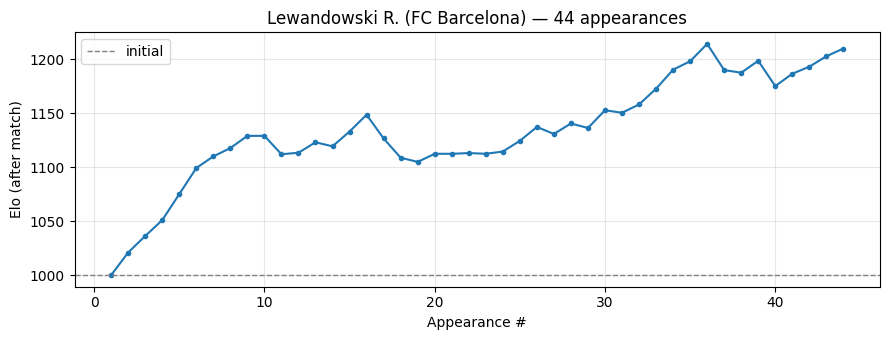

In [5]:
player = "Lewandowski R."
sub = barca[barca.Player == player].sort_values("round").reset_index(drop=True)

plt.figure(figsize=(9, 3.5))
plt.plot(range(1, len(sub) + 1), sub["rating"], marker="o", ms=3)
plt.axhline(1000, color="grey", ls="--", lw=1, label="initial")
plt.xlabel("Appearance #"); plt.ylabel("Elo (after match)")
plt.title(f"{player} (FC Barcelona) — {len(sub)} appearances")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

**Caveats.** Players are keyed by name (no IDs), so abbreviated names can collide across clubs.
`round` is a per-season chronological index, not a league matchday. `rating` is post-match.